In [1]:
import librosa
import numpy as np
from scipy.stats import kurtosis
import os

In [130]:
def extract_short_window_features(signal, sr, window=32, hop=16):
    features = {}
    
    # Zero-crossing rate - captures discontinuous, explosive nature
    features['zcr'] = librosa.feature.zero_crossing_rate(
        signal, frame_length=window, hop_length=hop,center =False)[0]
    
    # RMS energy - captures sudden amplitude spikes
    features['rms'] = librosa.feature.rms(
        y=signal, frame_length=window, hop_length=hop,center=False)[0]
    
    # Spectral flux - requires custom calculation
    features['flux'] = compute_spectral_flux(signal, sr, window, hop)
    
    # Summary statistics
    summary = {
        'short_zcr': features['zcr'],
        'short_rms': features['rms'],
        'short_flux': features['flux']
    }
    
    return summary

def extract_long_window_features(signal, sr, window=256, hop=128):
    features = {}
    
    # Spectral centroid - wheezes have concentrated frequency content
    features['centroid'] = librosa.feature.spectral_centroid(
        y=signal, sr=sr, n_fft=window, hop_length=hop,center=False)[0]
    
    # Spectral bandwidth - wheezes are narrow-band
    features['bandwidth'] = librosa.feature.spectral_bandwidth(
        y=signal, sr=sr, n_fft=window, hop_length=hop,center=False)[0]
    
    # Spectral rolloff
    features['rolloff'] = librosa.feature.spectral_rolloff(
        y=signal, sr=sr, n_fft=window, hop_length=hop,center=False)[0]
    
    # Spectral flatness - wheezes are tonal (low flatness)
    features['flatness'] = librosa.feature.spectral_flatness(
        y=signal, n_fft=window, hop_length=hop,center=False)[0]
    
    # MFCCs - capture overall spectral shape
    mfccs = librosa.feature.mfcc(
        y=signal, sr=sr, n_mfcc=13, n_fft=window, hop_length=hop,center=False)
    
    # Summary statistics
    summary = {
        'long_centroid': features['centroid'],
        'long_bandwidth': features['bandwidth'],
        'long_rolloff': features['rolloff'],
        'long_flatness': features['flatness']
    }
    
    # Add MFCC statistics
    for i in range(mfccs.shape[0]):
        summary[f'long_mfcc_{i+1}'] = mfccs[i]
    
    return summary

def extract_respiratory_features(signal, sr,short_window=32,long_window=256):

    short_hop = short_window // 2
    long_hop = long_window // 2
    
    short_feats = extract_short_window_features(signal, sr, short_window, short_hop)
    long_feats = extract_long_window_features(signal, sr, long_window, long_hop)
    
    all_features = {**short_feats, **long_feats}
    feature_vector = np.array(list(all_features.values()))
    feature_names = list(all_features.keys())
    
    return feature_vector, feature_names


def compute_spectral_flux(signal, sr, window=32, hop=16):
    """
    Compute spectral flux across frames
    Measures how quickly the power spectrum changes
    """

    n_fft = min(64, window)
    
    # Compute STFT
    S = np.abs(librosa.stft(signal, n_fft=n_fft, hop_length=hop, 
                            win_length=window,center=False))
    
    # Normalize each frame
    S_normalized = S / (S.sum(axis=0) + 1e-10)
    
    # Compute flux between consecutive frames
    flux = np.sqrt(np.sum(np.diff(S_normalized, axis=1)**2, axis=0))
    
    return flux

In [141]:
%matplotlib widget

Eko_p002_t01_severe_20250221.wav


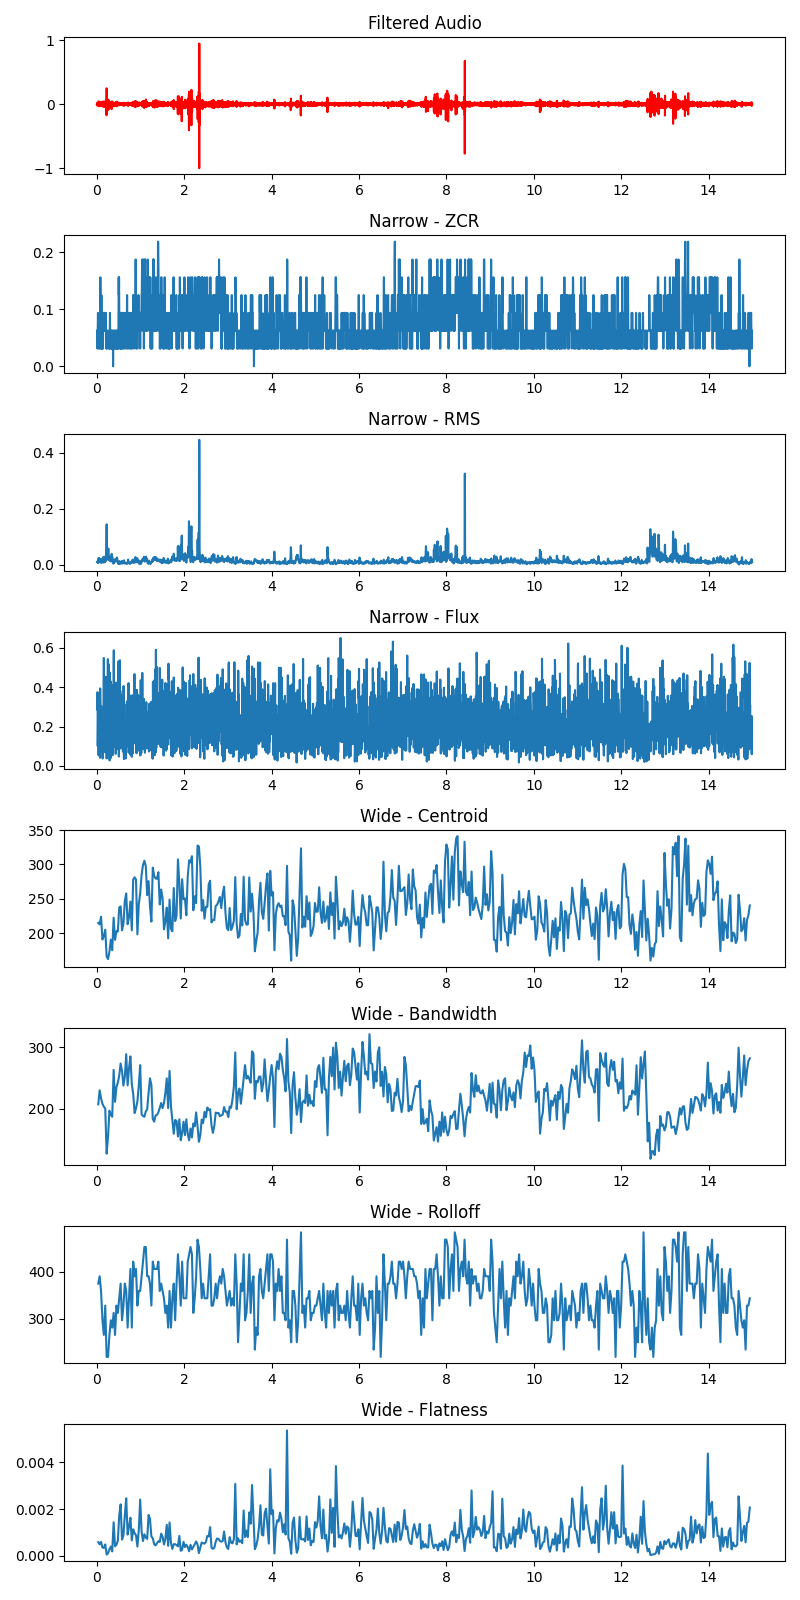

In [153]:
import wav_utils
import matplotlib.pyplot as plt


dataFolder = "Samples"

data_files = sorted(os.listdir(dataFolder))

data_files = ['Eko_p002_t01_severe_20250221.wav']
#data_files = ['Eko_p003_t01_moderate_20250227.wav']

allFeatures = []

diagnosis_score = {
    'healthy': 0,
    'mild': 1,
    'moderate': 2,
    'severe': 3
}

allScores = []

for data_file in data_files:

    #if not a wav file, skip
    if ".wav" not in data_file:
        continue

    if data_file.startswith('Eko_p008'):
        continue

    print(data_file)
    allScores.append(diagnosis_score[data_file.split('_')[3]])

    # path
    wavFilepath = f"{dataFolder}/{data_file}"

    # load data
    raw_audio, sample_rate = librosa.load(path=wavFilepath, sr=4000)

    # Noise reduction method, filter
    filter_lowcut = 80
    filter_highcut = 1800
    filter_order = 8
    filter_btype = "bandpass"  
    filt_audio = wav_utils.filter_denoise(raw_audio, sample_rate, filter_order,
                                    filter_lowcut, filter_highcut, btype=filter_btype)

    # Normalise and remove DC component in signal
    filt_audio = wav_utils.dc_normalise(filt_audio)  

    narrow_win =32
    narrow_hop =16

    wide_win = 256
    wide_hop = 128


    short_feats = extract_short_window_features(filt_audio, sample_rate, window=narrow_win, hop=narrow_hop)
    long_feats = extract_long_window_features(filt_audio, sample_rate, window=wide_win, hop=wide_hop)

    t_total = (len(filt_audio)) / sample_rate
    t = np.array(range(1,len(filt_audio)+1))*(1/sample_rate) 
    t_short = np.array(range(1,len(short_feats['short_zcr'])+1))*(narrow_hop/sample_rate) 
    t_short_flux = t_short[:-1] + np.diff(t_short)
    t_long = np.array(range(1,len(long_feats['long_centroid'])+1))*(wide_hop/sample_rate) 

    fig = plt.figure(figsize=(8,16))

    ax1 = fig.add_subplot(8,1,1)
    ax1.plot(t,filt_audio,'r')
    ax1.set_title('Filtered Audio')

    ax2 = fig.add_subplot(8,1,2,sharex=ax1)
    ax2.plot(t_short,short_feats['short_zcr'])
    ax2.set_title('Narrow - ZCR')


    ax3 = fig.add_subplot(8,1,3,sharex=ax1)
    ax3.plot(t_short,short_feats['short_rms'])
    ax3.set_title('Narrow - RMS')

    ax4 = fig.add_subplot(8,1,4,sharex=ax1)
    ax4.plot(t_short_flux,short_feats['short_flux'])
    ax4.set_title('Narrow - Flux')

    ax5 = fig.add_subplot(8,1,5,sharex=ax1)
    ax5.plot(t_long,long_feats['long_centroid'])
    ax5.set_title('Wide - Centroid')

    ax6 = fig.add_subplot(8,1,6,sharex=ax1)
    ax6.plot(t_long,long_feats['long_bandwidth'])
    ax6.set_title('Wide - Bandwidth')

    ax7 = fig.add_subplot(8,1,7,sharex=ax1)
    ax7.plot(t_long,long_feats['long_rolloff'])
    ax7.set_title('Wide - Rolloff')
    
    ax8 = fig.add_subplot(8,1,8,sharex=ax1)
    ax8.plot(t_long,long_feats['long_flatness'])
    ax8.set_title('Wide - Flatness')

    plt.tight_layout()
    plt.show()

    

In [143]:
len(t)

60000

In [144]:
t

array([2.500000e-04, 5.000000e-04, 7.500000e-04, ..., 1.499950e+01,
       1.499975e+01, 1.500000e+01])